# TP - Clasificación Multiclase de Texto con Regresión Softmax
### Redes Neuronales / Deep Learning

Dataset: **20 Newsgroups** (~18.000 posts de foros de Usenet, clasificados en 20 categorías).

## Objetivos
- Implementar un pipeline de preprocesamiento de texto **configurable** (stopwords, stemming, lematización, n-gramas).
- Implementar una **Regresión Softmax** (regresión logística multinomial) en PyTorch: una única capa lineal + `CrossEntropyLoss`, sin capas ocultas.
- Trackear el entrenamiento con **TensorBoard** y **MLflow**.
- Usar **Optuna** para buscar la mejor combinación de hiperparámetros de preprocesamiento *y* de entrenamiento en conjunto.

## Qué hay que completar
Los bloques marcados `# TODO` son los que tienen que completar ustedes. El resto ya está resuelto.

Esta notebook es individual/standalone: no tiene una sección de defensa grupal asociada.


## 0. Setup

In [2]:
import re
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

from torch.utils.tensorboard import SummaryWriter
import mlflow
import mlflow.pytorch
import optuna

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)


/Users/emanuel/Documents/NLP/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Usando dispositivo: cpu


In [3]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("punkt")
nltk.download("punkt_tab")


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/emanuel/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /Users/emanuel/nltk_data...
[nltk_data] Downloading package omw-1.4 to /Users/emanuel/nltk_data...
[nltk_data] Downloading package punkt to /Users/emanuel/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/emanuel/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## 1. Datos: 20 Newsgroups

Usamos `remove=('headers', 'footers', 'quotes')` para sacar metadata que haría el problema "demasiado fácil" (por ejemplo, el header a veces incluye el nombre del newsgroup).

In [4]:
newsgroups_train = fetch_20newsgroups(subset="train", remove=("headers", "footers", "quotes"))
newsgroups_test  = fetch_20newsgroups(subset="test",  remove=("headers", "footers", "quotes"))

class_names = newsgroups_train.target_names
NUM_CLASSES = len(class_names)
print(f"Clases ({NUM_CLASSES}):", class_names)
print(f"\nTrain: {len(newsgroups_train.data)} documentos | Test: {len(newsgroups_test.data)} documentos")

print("\n--- Ejemplo de documento ---")
print("Categoría:", class_names[newsgroups_train.target[0]])
print(newsgroups_train.data[0][:500])


Clases (20): ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']

Train: 11314 documentos | Test: 7532 documentos

--- Ejemplo de documento ---
Categoría: rec.autos
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.


## 2. Preprocesamiento configurable

Vamos a armar una función de preprocesamiento con estos hiperparámetros (todos van a formar parte de la búsqueda de Optuna más adelante):

- `remove_stopwords` (`True`/`False`): sacar palabras muy frecuentes y poco informativas (`the`, `is`, `and`, ...).
- `normalization` (`"none"` / `"stem"` / `"lemmatize"`):
  - `"none"`: no se normaliza la palabra.
  - `"stem"`: **stemming** con Porter Stemmer — corta la palabra a una raíz heurística (`"running"` → `"run"`, a veces resultados no son palabras reales: `"studies"` → `"studi"`).
  - `"lemmatize"`: **lematización** con WordNet — lleva la palabra a su forma de diccionario (`"running"` → `"run"`, `"studies"` → `"study"`), más lenta pero más "correcta" lingüísticamente.

### TODO 1: completar `preprocess_text`

Pasos esperados:
1. Tokenizar el texto con `word_tokenize`.
2. Pasar todo a minúsculas y quedarse solo con tokens alfabéticos (`token.isalpha()`), para descartar números y puntuación.
3. Si `remove_stopwords` es `True`, sacar los tokens que estén en el set de stopwords.
4. Según `normalization`, aplicar `stemmer.stem(token)`, `lemmatizer.lemmatize(token)`, o dejar el token igual.
5. Devolver los tokens unidos con espacios (un string, para poder pasárselo después a `TfidfVectorizer`).

In [5]:
STOP_WORDS = set(stopwords.words("english"))
STEMMER = PorterStemmer()
LEMMATIZER = WordNetLemmatizer()


def preprocess_text(text, remove_stopwords, normalization):
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha()]

    # TODO: si remove_stopwords es True, filtrar los tokens que están en STOP_WORDS
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOP_WORDS]  # reemplazar por el filtrado correcto

    # TODO: aplicar la normalización correspondiente según el valor de `normalization`
    if normalization == "stem":
        tokens = [STEMMER.stem(t) for t in tokens]  # reemplazar: aplicar STEMMER.stem a cada token
    elif normalization == "lemmatize":
        tokens = [LEMMATIZER.lemmatize(t) for t in tokens] # reemplazar: aplicar LEMMATIZER.lemmatize a cada token
    # si normalization == "none", no se hace nada más

    return " ".join(tokens)


In [6]:
# Sanity check: probamos las distintas combinaciones sobre una oración de ejemplo
ejemplo = "The researchers were studying the running processes and stopping conditions of the engines."
for norm in ["none", "stem", "lemmatize"]:
    for rm_sw in [False, True]:
        resultado = preprocess_text(ejemplo, remove_stopwords=rm_sw, normalization=norm)
        print(f"normalization={norm:10s} remove_stopwords={str(rm_sw):5s} -> {resultado}")


normalization=none       remove_stopwords=False -> the researchers were studying the running processes and stopping conditions of the engines
normalization=none       remove_stopwords=True  -> researchers studying running processes stopping conditions engines
normalization=stem       remove_stopwords=False -> the research were studi the run process and stop condit of the engin
normalization=stem       remove_stopwords=True  -> research studi run process stop condit engin
normalization=lemmatize  remove_stopwords=False -> the researcher were studying the running process and stopping condition of the engine
normalization=lemmatize  remove_stopwords=True  -> researcher studying running process stopping condition engine


## 3. Vectorización TF-IDF

Convertimos los textos preprocesados en vectores numéricos con `TfidfVectorizer`. Como el preprocesamiento (tokenización, stopwords, normalización) ya lo hicimos nosotros, acá solo controlamos:

- `ngram_range`: `(1,1)` solo unigramas, o `(1,2)` unigramas + bigramas (captura algo de contexto, ej. `"new york"`).
- `max_features`: tamaño máximo del vocabulario (se queda con los términos más frecuentes).
- `min_df`: un término tiene que aparecer en al menos `min_df` documentos para entrar al vocabulario (filtra términos rarísimos / errores de tipeo).

### TODO 2: completar `vectorize_data`

In [16]:
def vectorize_data(train_texts, test_texts, ngram_range, max_features, min_df):
    # TODO: crear un TfidfVectorizer con los parámetros recibidos y ajustarlo (fit) sobre train_texts,
    # después transformar train_texts y test_texts con ese mismo vectorizer.
    vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=5000, min_df=2)  # TfidfVectorizer(ngram_range=..., max_features=..., min_df=...)
    X_train = vectorizer.fit_transform(train_texts)     # vectorizer.fit_transform(train_texts)
    X_test = vectorizer.transform(test_texts)       # vectorizer.transform(test_texts)
    return X_train, X_test, vectorizer


In [17]:
# Sanity check rápido con pocos documentos
_sample_train = ["the cat sat on the mat", "dogs are running in the park", "cats and dogs are pets"]
_sample_test = ["the dog sat on the mat"]
_Xtr, _Xte, _vec = vectorize_data(_sample_train, _sample_test, ngram_range=(1, 1), max_features=50, min_df=3)
assert _Xtr is not None, "Completá vectorize_data"
print("Shape train:", _Xtr.shape, "| Shape test:", _Xte.shape)
print("Vocabulario (parcial):", list(_vec.vocabulary_.keys())[:10])


Shape train: (3, 4) | Shape test: (1, 4)
Vocabulario (parcial): ['the', 'dogs', 'are', 'dogs are']


## 4. Modelo: Regresión Softmax

La regresión softmax (regresión logística multinomial) es el modelo más simple posible para clasificación multiclase: **una sola capa lineal** que mapea el vector de entrada a un score (logit) por clase, sin ninguna no-linealidad ni capa oculta.

`CrossEntropyLoss` de PyTorch ya incluye internamente un `log_softmax` + `NLLLoss`, así que el modelo **no debe aplicar softmax en el forward** — hay que devolver los logits crudos.

### TODO 3: completar `SoftmaxRegression`

In [18]:
class SoftmaxRegression(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        # TODO: definir una única capa lineal de input_dim a num_classes
        self.linear = nn.Linear(input_dim, num_classes)
        
    def forward(self, x):
        # TODO: devolver los logits (salida de self.linear), SIN aplicar softmax
        return self.linear(x)


In [19]:
# Sanity check
_dummy = torch.randn(4, 50)
_model_check = SoftmaxRegression(input_dim=50, num_classes=20)
_out = _model_check(_dummy)
assert _out is not None and _out.shape == (4, 20), "Revisá SoftmaxRegression"
print("Shape de salida OK:", _out.shape)


Shape de salida OK: torch.Size([4, 20])


## 5. Entrenamiento (ya resuelto)

Dado que los datos vectorizados entran en memoria sin problema, armamos `DataLoader`s a partir de tensores densos. Logueamos loss y accuracy (train y validación) por época a TensorBoard, y a MLflow además los hiperparámetros y el modelo final.

In [20]:
%load_ext tensorboard


In [21]:
def to_tensor_dataset(X, y):
    X_dense = torch.tensor(X.toarray(), dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)
    return TensorDataset(X_dense, y_tensor)


def train_softmax_model(model, train_loader, val_loader, optimizer, epochs, writer=None, run_name="softmax"):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += xb.size(0)
        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                running_loss += loss.item() * xb.size(0)
                correct += (logits.argmax(dim=1) == yb).sum().item()
                total += xb.size(0)
        val_loss, val_acc = running_loss / total, correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"[{run_name}] Epoch {epoch+1}/{epochs} - "
              f"train_loss: {train_loss:.4f} train_acc: {train_acc:.4f} - "
              f"val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}")

        if writer is not None:
            writer.add_scalars("loss", {"train": train_loss, "val": val_loss}, epoch)
            writer.add_scalars("accuracy", {"train": train_acc, "val": val_acc}, epoch)
        mlflow.log_metric("train_loss", train_loss, step=epoch)
        mlflow.log_metric("val_loss", val_loss, step=epoch)
        mlflow.log_metric("train_acc", train_acc, step=epoch)
        mlflow.log_metric("val_acc", val_acc, step=epoch)

    return history


## 6. Búsqueda de hiperparámetros con Optuna

La búsqueda incluye **hiperparámetros de preprocesamiento** (`remove_stopwords`, `normalization`, `ngram_range`, `max_features`, `min_df`) y **de entrenamiento** (`lr`, `batch_size`), todos en un mismo `objective`.

**Optimización de tiempo**: como la tokenización + stopwords + normalización es lo más lento del pipeline (y solo depende de `remove_stopwords` y `normalization`, que tienen pocas combinaciones posibles), la precalculamos una sola vez para las 6 combinaciones posibles y la cacheamos. Así, cada trial de Optuna solo repite la parte rápida (vectorizar + entrenar pocas épocas).

In [22]:
print("Precalculando preprocesamiento para las 6 combinaciones posibles (puede tardar unos minutos)...")
preprocessed_cache = {}
for remove_stopwords in [False, True]:
    for normalization in ["none", "stem", "lemmatize"]:
        key = (remove_stopwords, normalization)
        train_proc = [preprocess_text(t, remove_stopwords, normalization) for t in newsgroups_train.data]
        test_proc  = [preprocess_text(t, remove_stopwords, normalization) for t in newsgroups_test.data]
        preprocessed_cache[key] = (train_proc, test_proc)
        print("  listo:", key)


Precalculando preprocesamiento para las 6 combinaciones posibles (puede tardar unos minutos)...
  listo: (False, 'none')
  listo: (False, 'stem')
  listo: (False, 'lemmatize')
  listo: (True, 'none')
  listo: (True, 'stem')
  listo: (True, 'lemmatize')


In [23]:
def objective(trial):
    remove_stopwords = trial.suggest_categorical("remove_stopwords", [False, True])
    normalization = trial.suggest_categorical("normalization", ["none", "stem", "lemmatize"])
    ngram_range = trial.suggest_categorical("ngram_range", ["1gram", "1_2gram"])
    ngram_range_tuple = (1, 1) if ngram_range == "1gram" else (1, 2)
    max_features = trial.suggest_categorical("max_features", [2000, 5000, 10000])
    min_df = trial.suggest_categorical("min_df", [1, 2, 5])
    lr = trial.suggest_float("lr", 1e-3, 1e-1, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    train_texts, test_texts = preprocessed_cache[(remove_stopwords, normalization)]
    # Partimos una porción de train como validación para la búsqueda (no usamos el test acá)
    tr_texts, val_texts, tr_labels, val_labels = train_test_split(
        train_texts, newsgroups_train.target, test_size=0.2, random_state=SEED,
        stratify=newsgroups_train.target,
    )

    X_tr, X_val, _ = vectorize_data(tr_texts, val_texts, ngram_range_tuple, max_features, min_df)
    train_loader = DataLoader(to_tensor_dataset(X_tr, tr_labels), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(to_tensor_dataset(X_val, val_labels), batch_size=batch_size, shuffle=False)

    model = SoftmaxRegression(input_dim=X_tr.shape[1], num_classes=NUM_CLASSES)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = train_softmax_model(model, train_loader, val_loader, optimizer, epochs=5, run_name=f"trial_{trial.number}")

    return history["val_acc"][-1]


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

print("Mejores hiperparámetros:", study.best_params)
print("Mejor accuracy de validación:", study.best_value)


[I 2026-09-29 23:53:59,092] A new study created in memory with name: no-name-9d992003-efe2-462e-ba27-3a52a2782eb6


[trial_0] Epoch 1/5 - train_loss: 2.1387 train_acc: 0.5863 - val_loss: 1.5731 val_acc: 0.6924


2026/09/29 23:54:18 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/29 23:54:18 INFO mlflow.store.db.utils: Updating database tables


[trial_0] Epoch 2/5 - train_loss: 1.0983 train_acc: 0.8371 - val_loss: 1.2478 val_acc: 0.7079
[trial_0] Epoch 3/5 - train_loss: 0.7527 train_acc: 0.8848 - val_loss: 1.1240 val_acc: 0.7084
[trial_0] Epoch 4/5 - train_loss: 0.5714 train_acc: 0.9135 - val_loss: 1.0682 val_acc: 0.7088


[I 2026-09-29 23:54:23,808] Trial 0 finished with value: 0.7061422889969068 and parameters: {'remove_stopwords': True, 'normalization': 'stem', 'ngram_range': '1gram', 'max_features': 2000, 'min_df': 5, 'lr': 0.010858316729327386, 'batch_size': 32}. Best is trial 0 with value: 0.7061422889969068.


...

[trial_12] Epoch 5/5 - train_loss: 0.2258 train_acc: 0.9629 - val_loss: 1.0360 val_acc: 0.6960
[trial_13] Epoch 1/5 - train_loss: 2.7392 train_acc: 0.5031 - val_loss: 2.4956 val_acc: 0.6350
[trial_13] Epoch 2/5 - train_loss: 2.1972 train_acc: 0.7745 - val_loss: 2.1406 val_acc: 0.6633
[trial_13] Epoch 3/5 - train_loss: 1.8085 train_acc: 0.8287 - val_loss: 1.8892 val_acc: 0.6779
[trial_13] Epoch 4/5 - train_loss: 1.5232 train_acc: 0.8508 - val_loss: 1.7105 val_acc: 0.6858


[I 2026-09-29 23:56:35,720] Trial 13 finished with value: 0.692001767565179 and parameters: {'remove_stopwords': True, 'normalization': 'none', 'ngram_range': '1gram', 'max_features': 2000, 'min_df': 5, 'lr': 0.0025652010790547936, 'batch_size': 32}. Best is trial 11 with value: 0.7079098541758727.


[trial_13] Epoch 5/5 - train_loss: 1.3097 train_acc: 0.8686 - val_loss: 1.5798 val_acc: 0.6920
[trial_14] Epoch 1/5 - train_loss: 2.8369 train_acc: 0.5054 - val_loss: 2.6752 val_acc: 0.6399
[trial_14] Epoch 2/5 - train_loss: 2.4821 train_acc: 0.7575 - val_loss: 2.4119 val_acc: 0.6628
[trial_14] Epoch 3/5 - train_loss: 2.1885 train_acc: 0.7943 - val_loss: 2.1947 val_acc: 0.6752
[trial_14] Epoch 4/5 - train_loss: 1.9427 train_acc: 0.8228 - val_loss: 2.0168 val_acc: 0.6836


[I 2026-09-29 23:56:44,101] Trial 14 finished with value: 0.692001767565179 and parameters: {'remove_stopwords': True, 'normalization': 'stem', 'ngram_range': '1_2gram', 'max_features': 2000, 'min_df': 5, 'lr': 0.0021413707409179365, 'batch_size': 64}. Best is trial 11 with value: 0.7079098541758727.


[trial_14] Epoch 5/5 - train_loss: 1.7382 train_acc: 0.8419 - val_loss: 1.8716 val_acc: 0.6920
Mejores hiperparámetros: {'remove_stopwords': True, 'normalization': 'stem', 'ngram_range': '1gram', 'max_features': 2000, 'min_df': 2, 'lr': 0.003915978688218844, 'batch_size': 32}
Mejor accuracy de validación: 0.7079098541758727


## 7. Entrenamiento final

Usamos los mejores hiperparámetros encontrados por Optuna, entrenamos con **todo** el train set y por más épocas, evaluando contra el test set real (que no se usó en la búsqueda).

In [27]:
mlflow.end_run()
best = study.best_params
BEST_REMOVE_SW = best["remove_stopwords"]
BEST_NORM = best["normalization"]
BEST_NGRAM = (1, 1) if best["ngram_range"] == "1gram" else (1, 2)
BEST_MAX_FEATURES = best["max_features"]
BEST_MIN_DF = best["min_df"]
BEST_LR = best["lr"]
BEST_BATCH_SIZE = best["batch_size"]
EPOCHS_FINAL = 20

train_texts_final, test_texts_final = preprocessed_cache[(BEST_REMOVE_SW, BEST_NORM)]
X_train_final, X_test_final, vectorizer_final = vectorize_data(
    train_texts_final, test_texts_final, BEST_NGRAM, BEST_MAX_FEATURES, BEST_MIN_DF
)

train_loader_final = DataLoader(to_tensor_dataset(X_train_final, newsgroups_train.target),
                                 batch_size=BEST_BATCH_SIZE, shuffle=True)
test_loader_final = DataLoader(to_tensor_dataset(X_test_final, newsgroups_test.target),
                                batch_size=BEST_BATCH_SIZE, shuffle=False)

model = SoftmaxRegression(input_dim=X_train_final.shape[1], num_classes=NUM_CLASSES)
optimizer = optim.Adam(model.parameters(), lr=BEST_LR)
writer = SummaryWriter(log_dir="runs/softmax_final")

mlflow.set_experiment("softmax_20newsgroups")
with mlflow.start_run(run_name="softmax_final"):
    mlflow.log_params({
        "remove_stopwords": BEST_REMOVE_SW, "normalization": BEST_NORM,
        "ngram_range": str(BEST_NGRAM), "max_features": BEST_MAX_FEATURES, "min_df": BEST_MIN_DF,
        "lr": BEST_LR, "batch_size": BEST_BATCH_SIZE, "epochs": EPOCHS_FINAL,
    })
    history = train_softmax_model(model, train_loader_final, test_loader_final, optimizer,
                                   epochs=EPOCHS_FINAL, writer=writer, run_name="final")
    mlflow.pytorch.log_model(model,"model",serialization_format="pickle")

writer.close()


[final] Epoch 1/20 - train_loss: 2.5137 train_acc: 0.5709 - val_loss: 2.1942 val_acc: 0.6322
[final] Epoch 2/20 - train_loss: 1.7253 train_acc: 0.7903 - val_loss: 1.7936 val_acc: 0.6511
[final] Epoch 3/20 - train_loss: 1.3044 train_acc: 0.8320 - val_loss: 1.5798 val_acc: 0.6541
[final] Epoch 4/20 - train_loss: 1.0507 train_acc: 0.8572 - val_loss: 1.4547 val_acc: 0.6536
[final] Epoch 5/20 - train_loss: 0.8823 train_acc: 0.8738 - val_loss: 1.3750 val_acc: 0.6527
[final] Epoch 6/20 - train_loss: 0.7613 train_acc: 0.8877 - val_loss: 1.3232 val_acc: 0.6515
[final] Epoch 7/20 - train_loss: 0.6694 train_acc: 0.9001 - val_loss: 1.2878 val_acc: 0.6508
[final] Epoch 8/20 - train_loss: 0.5963 train_acc: 0.9088 - val_loss: 1.2628 val_acc: 0.6495
[final] Epoch 9/20 - train_loss: 0.5369 train_acc: 0.9176 - val_loss: 1.2457 val_acc: 0.6470
[final] Epoch 10/20 - train_loss: 0.4875 train_acc: 0.9260 - val_loss: 1.2342 val_acc: 0.6466
[final] Epoch 11/20 - train_loss: 0.4453 train_acc: 0.9320 - val_loss

2026/09/30 00:06:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/30 00:06:41 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


[final] Epoch 20/20 - train_loss: 0.2380 train_acc: 0.9616 - val_loss: 1.2559 val_acc: 0.6317


In [32]:
%tensorboard --logdir runs


Reusing TensorBoard on port 6006 (pid 4676), started 6:10:20 ago. (Use '!kill 4676' to kill it.)

## 8. Evaluación final

In [29]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader_final:
        xb = xb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

test_accuracy = accuracy_score(all_labels, all_preds)
print(f"Accuracy en test: {test_accuracy:.4f}\n")
print(classification_report(all_labels, all_preds, target_names=class_names))


Accuracy en test: 0.6317

                          precision    recall  f1-score   support

             alt.atheism       0.45      0.44      0.44       319
           comp.graphics       0.57      0.58      0.57       389
 comp.os.ms-windows.misc       0.60      0.58      0.59       394
comp.sys.ibm.pc.hardware       0.59      0.57      0.58       392
   comp.sys.mac.hardware       0.64      0.61      0.62       385
          comp.windows.x       0.74      0.64      0.69       395
            misc.forsale       0.73      0.75      0.74       390
               rec.autos       0.64      0.64      0.64       396
         rec.motorcycles       0.70      0.68      0.69       398
      rec.sport.baseball       0.52      0.80      0.63       397
        rec.sport.hockey       0.88      0.84      0.86       399
               sci.crypt       0.77      0.69      0.73       396
         sci.electronics       0.53      0.54      0.53       393
                 sci.med       0.73      0.68    

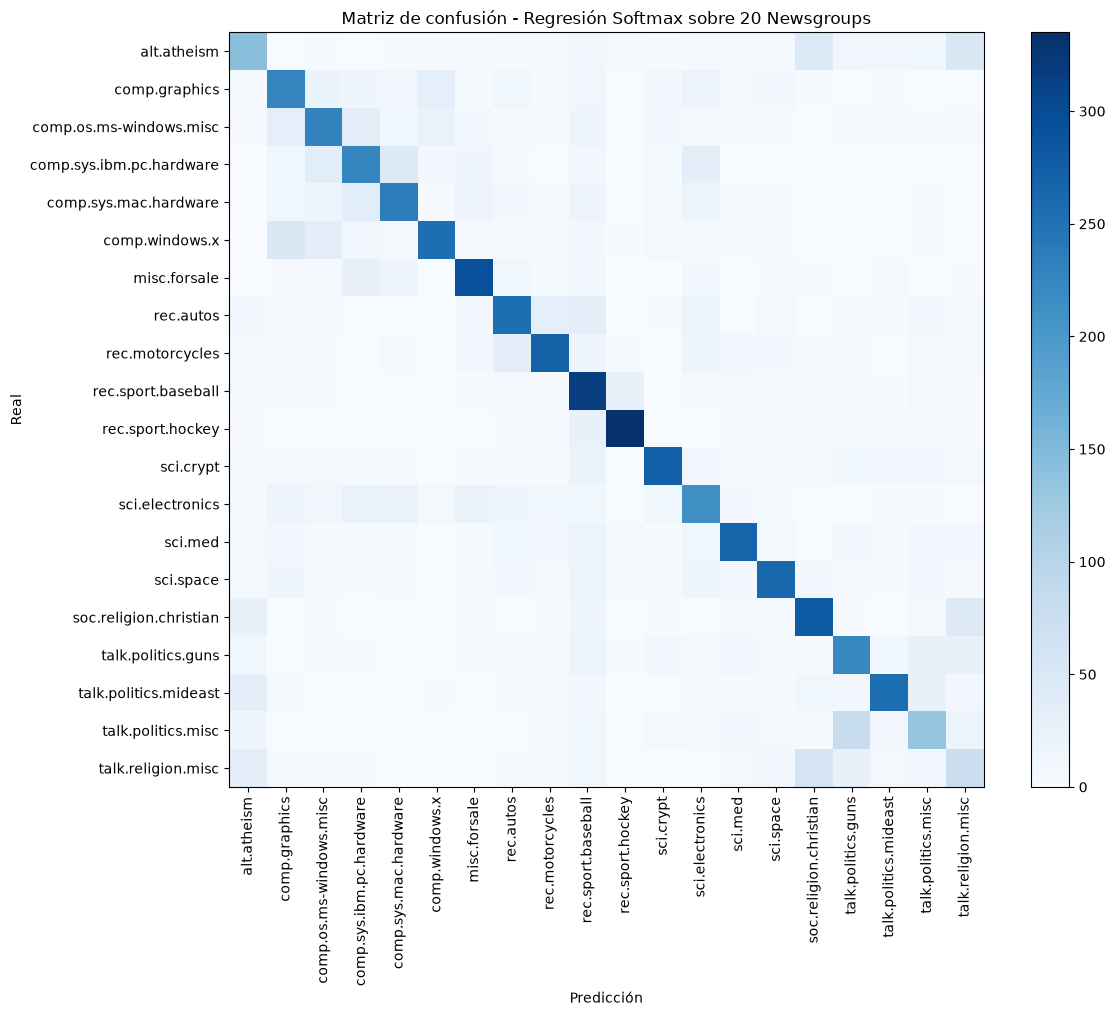

In [30]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(NUM_CLASSES), class_names, rotation=90)
plt.yticks(range(NUM_CLASSES), class_names)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Regresión Softmax sobre 20 Newsgroups")
plt.tight_layout()
plt.show()


## 9. Preguntas de reflexión

**Sobre Regresión Softmax (teoría)**
1. ¿Por qué la regresión softmax es una generalización de la regresión logística binaria? ¿Qué pasaría si `NUM_CLASSES = 2`?

La regresión logística binaria permite clasificar ejemplos entre dos clases, asignando una probabilidad a cada una. La regresión softmax extiende este concepto al caso de múltiples clases, ya que calcula una probabilidad para cada una de las categorías posibles. Cuando NUM_CLASSES = 2, el modelo se comporta como un clasificador binario y es equivalente a una regresión logística, aunque la implementación mediante softmax utiliza dos logits en lugar de un único valor.

2. ¿Por qué `CrossEntropyLoss` en PyTorch no necesita que se le aplique `softmax` antes en el forward? ¿Qué pasaría si igual lo aplicaran (softmax + CrossEntropyLoss)?

`CrossEntropyLoss` de PyTorch ya incluye internamente un `log_softmax` + `NLLLoss`, así que el modelo no debe aplicar softmax en el forward — hay que devolver los logits crudos. Si se aplicara previamente, se estaría pasando a CrossEntropyLoss un resultado que ya fue transformado en probabilidades, cuando la función espera los logits originales

3. ¿Qué tipo de frontera de decisión puede aprender un modelo de regresión softmax? ¿Qué limitación tiene frente a un problema que no es linealmente separable?

La regresión softmax aprende fronteras de decisión lineales. Esto significa que puede separar las distintas clases mediante rectas, planos o hiperplanos, dependiendo de la cantidad de características utilizadas. Su principal limitación es que no puede representar por sí sola relaciones no lineales entre las características. Por lo tanto, si las clases requieren una frontera de decisión compleja para poder separarse correctamente, el modelo tendrá dificultades para clasificarlas aunque se entrene correctamente.

4. ¿En qué se diferencia este modelo de una red neuronal con capas ocultas? ¿En qué situación elegirían una sobre la otra?

La regresión softmax utilizada en este trabajo solamente posee una capa lineal que transforma directamente las características de entrada en los logits de las clases. Una red neuronal con capas ocultas, en cambio, puede realizar varias transformaciones sucesivas e incorporar funciones de activación no lineales. Esto le permite aprender relaciones más complejas entre las características. La regresión softmax puede ser una buena elección cuando se busca un modelo simple y rápido, especialmente como modelo de referencia, mientras que una red neuronal con capas ocultas puede ser más apropiada cuando el problema presenta relaciones no lineales que el modelo lineal no puede representar.

**Sobre frameworks y herramientas**

5. ¿Qué ventajas y desventajas tiene implementar esto en PyTorch (como hicimos) comparado con usar directamente `sklearn.linear_model.LogisticRegression(multi_class="multinomial")`?

Implementar el modelo en PyTorch permite tener un mayor control sobre su arquitectura y sobre el proceso de entrenamiento. En particular, permite definir explícitamente el forward, la función de pérdida, el optimizador, el tamaño de los batches y otros aspectos del entrenamiento, además de facilitar la posterior extensión hacia redes neuronales más complejas. La desventaja es que requiere implementar y configurar una mayor cantidad de elementos. En cambio, LogisticRegression de Scikit-learn permite entrenar una regresión logística de manera mucho más directa y sencilla, pero ofrece menos flexibilidad para modificar la arquitectura y el procedimiento de entrenamiento.

6. ¿Para qué sirvió específicamente MLflow en este TP? ¿En qué se diferencia de lo que loguea TensorBoard?

MLflow se utilizó para registrar y organizar los diferentes experimentos realizados durante el entrenamiento, permitiendo guardar parámetros, configuraciones y métricas de cada ejecución para posteriormente compararlos. TensorBoard está más orientado a visualizar el comportamiento del entrenamiento, por ejemplo observando cómo evolucionan la pérdida o la precisión a medida que avanzan las épocas. Por lo tanto, mientras que MLflow facilita principalmente la organización y comparación de experimentos, TensorBoard facilita la visualización de las métricas y del proceso de entrenamiento.

7. ¿Qué ventaja concreta les dio Optuna frente a probar combinaciones de hiperparámetros a mano?

Optuna permitió automatizar la búsqueda de hiperparámetros y preprocesamientos, evitando tener que seleccionar y probar manualmente cada combinación posible. Además, utiliza los resultados de las pruebas anteriores para orientar la búsqueda hacia configuraciones que puedan ofrecer mejores resultados. Esto permite explorar un espacio de configuraciones mucho más grande de una manera más eficiente que realizando todas las pruebas manualmente.

**Sobre el experimento**

8. ¿Qué combinación de preprocesamiento (stopwords, stemming/lematización, n-gramas) encontró Optuna como mejor? ¿Tiene sentido para este dataset?

Optuna encontró como mejor configuración la eliminación de stopwords, stemming y el uso de unigramas, con un máximo de 2000 características y descartando las palabras que aparecen en un solo documento. Esta combinación tiene sentido para 20 Newsgroups porque eliminar stopwords reduce palabras poco informativas, el stemming agrupa distintas formas de una misma palabra y descartar términos extremadamente raros evita incorporar errores de tipeo o palabras muy específicas que podrían generar ruido o favorecer el sobreajuste. Además, limitar el vocabulario a 2000 características reduce la dimensionalidad del problema y la complejidad del modelo.

9. ¿En qué categorías del dataset se confunde más el modelo (según la matriz de confusión)? ¿Por qué creen que pasa (piensen en el contenido temático de esas categorías)?

El modelo se confunde al clasificar textos que corresponden a categorías similares en cuanto a temática. Por ejemplo, confunde entre ateismo, cristianismo y misc en religión. Esto se debe a que entre categorías similares se comparte mucho vocabulario, por lo que es más difícil discriminar entre ambas.

10. ¿Cambiaría su respuesta a la pregunta anterior si usaran un modelo con capas ocultas en vez de regresión softmax? ¿Por qué sí o por qué no?

Podría cambiar, ya que una red neuronal con capas ocultas puede aprender relaciones no lineales entre las características y, por lo tanto, encontrar patrones que la regresión softmax no puede representar.

## Análisis de la dinámica del entrenamiento

Durante las primeras épocas, el modelo aprende rápidamente. La accuracy de entrenamiento aumenta desde aproximadamente 0,63 hasta 0,70 en la primera época y luego continúa creciendo de manera progresiva hasta alcanzar 0,9616 en la época 19. De forma consistente, la loss de entrenamiento disminuye continuamente, pasando de valores superiores a 2 hasta aproximadamente 0,238 al final. Esto indica que el modelo sigue ajustándose cada vez mejor a los datos de entrenamiento.

Sin embargo, el comportamiento sobre el conjunto de validación es diferente. La accuracy de validación alcanza su máximo aproximadamente entre las épocas 2 y 3, con un valor cercano a 0,65, y a partir de ese momento comienza a disminuir lentamente hasta aproximadamente 0,632 en la época 19. Al mismo tiempo, la loss de validación disminuye durante gran parte del entrenamiento, pero se estabiliza aproximadamente entre las épocas 12 y 15 y presenta un pequeño aumento hacia el final. Esta diferencia entre entrenamiento y validación es indicativa de sobreajuste: el modelo continúa mejorando sobre los datos de entrenamiento, pero esa mejora no se traduce en un mejor desempeño sobre datos no vistos.

En particular, resulta interesante que la accuracy de validación alcance su máximo mucho antes de que termine el entrenamiento. Por lo tanto, entrenar durante las 20 épocas no parece ser lo más conveniente para la generalización. El modelo obtiene su mejor desempeño de validación aproximadamente en las primeras épocas y luego comienza a perder capacidad de generalización mientras continúa reduciendo la loss de entrenamiento.

## Análisis de la convergencia y tiempos

En términos de convergencia, la loss de entrenamiento todavía presenta una disminución apreciable al llegar a la época 19, por lo que el modelo no terminó de estabilizar completamente su aprendizaje sobre el conjunto de entrenamiento. En cambio, las métricas de validación se estabilizan mucho antes: la accuracy alcanza rápidamente un máximo y posteriormente permanece alrededor de 0,64, mientras que la loss de validación prácticamente deja de mejorar después de unas 12–15 épocas. Esto sugiere que el límite relevante para el modelo no está dado por su capacidad de seguir aprendiendo sobre entrenamiento, sino por su capacidad de generalizar.

El entrenamiento completo de 20 épocas tomó aproximadamente 22,2 segundos, lo que corresponde a alrededor de 1,1 segundos por época. Por lo tanto, desde el punto de vista temporal, continuar entrenando después de que las métricas de validación dejan de mejorar supone un costo computacional adicional sin una mejora equivalente en el desempeño de validación. En este caso, utilizar early stopping podría permitir detener el entrenamiento cerca del punto de mejor desempeño de validación y evitar parte del sobreajuste.